In [15]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt

from qutip import sigmax, sigmay, sigmaz, basis, sesolve, mesolve, Qobj, propagator, expect, tensor
from tqdm import tqdm

# nice colors for plots
colors = [
    '#222E50',
    '#8D99AE',
    '#E9D985',
    '#FF6B6C',
    '#285238',
]

# 6-1
## (a)


The reason we can disregard the spins of the electrons around the Yb nucleus but not those around alkalai metals is simply that Yb has 2 e- in its outer shell, for a total amount of even electrons. This naturally means that the ground state of the electron cloud is a singlet state with J=0. This eliminates hyperfine splitting while the electrons remain in this state.

## (b)

The biggest advantage of using 171-Yb as our atomic qubit is, in my opinion, the simplicity of the nuclear spin states. As mentioned in the paper, the 171-Yb nuclei is somewhat rare in that the only spin states with an I=1/2 the nuclei can exist in: -1/2 or +1/2. We can assume that in other nuclear systems, the nucleus could occupy other half-integer spin states, thus introducing the possibility of state leakage--removing us from the computational subspace and ruining our computations.

I think that the most challenging part of using the 171-Yb nucleus spin states as qubits stems from the fact that they are so large. Because they are very large nuclei, they will have a much lower magnetic moment than smaller nuclei, meaning the energy difference seen by an electron due to hyperfine splitting when excited will also be very small. This introduces a new kind of error: if your optical control system is too broad (even by a bit!) you risk accidentally exciting an unintended state, which destroys your computation. This would require more accurate lasers to work than, say, an NV-center qubit, where resonant frequancies of nuclei are relatively spread apart.


## (c)

Trapping occured at 486.78nm (novel wavelength)

Initialization was achieved at 556 nm light with optical pumping.

Readout is performed by autoionization from the Rydber state by a two photon process involving a 308 nm UV laser source and a 369 nm wavelength.

Single qubit manipulations are performed directly on the nucleus using an RF coil at around 3.09 kHz

Two-qubit manipulations are achieved using Rydberg blockade on the 556nm and 308nm sources. Also of note is that two-qubit gates can be surpressed by applying a shift to the global control field at 369nm.

## (d)

In [5]:
def H_drift(f_detuning):
    return f_detuning / 2 * sigmaz()

# By counting peaks in the paper, we'll set detuning =~ 12.5 peaks, t < 1
delta_synth = 2*np.pi * 12.5

def H_drive(f_rabi):
    return f_rabi/2 * sigmax()

f_rabi = 2*np.pi * 161.7

T_2 = 1.0 # s

# define a dephasing t_2 decay collapse operator.
C = [np.sqrt(1/(T_2*2)) * sigmaz()]

# Create delay mat:
T = np.linspace(0, 1.5, 1000)

P0_list = []

for t in tqdm(T):
    ket_init = basis(2, 1)
    H_tot = H_drift(delta_synth) + H_drive(f_rabi)
    # First sequence always same amount of time
    pulse_length = np.pi / (2 * f_rabi)
    t1 = np.linspace(0, pulse_length, 100)
    pulse1 = mesolve(H_tot, ket_init, t1, c_ops=C)

    # Free evolution
    t2 = np.linspace(0, t, 100)
    pulse2 = mesolve(H_drift(delta_synth), pulse1.final_state, t2, c_ops=C)

    # second pulse
    t3 = np.linspace(0, pulse_length, 100)
    sol = mesolve(H_tot, pulse2.final_state, t3, c_ops=C)

    # Final expectation
    P_0 = expect(qt.ket2dm(basis(2, 0)), sol.final_state)
    P0_list.append(P_0)


100%|██████████| 1000/1000 [00:03<00:00, 262.46it/s]


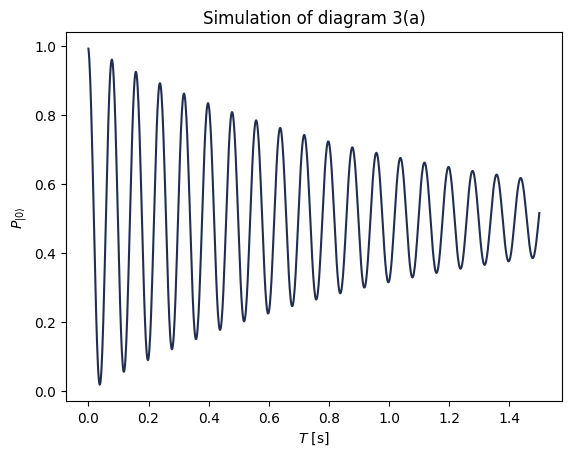

In [12]:
# plot
plt.title("Simulation of diagram 3(a)")
plt.plot(T, P0_list, color=colors[0])
plt.xlabel("$T$ [s]")
plt.ylabel(r"$P_{|0\rangle}$")
plt.show()

In [13]:
# NOTE: Maybe come back and do the gray part later??

## (e)
We can show how randomized benchmarking separates errors from state preparation/measurement from gate errors by looking at equation 1. If we set the circuit depth to 0, we get $R_S = 1 - \epsilon_{spam}$, which means that any error we measure at this depth is purely from measurement and initialization/preparation. However, as we scale up the depth of the randomized circuits, the probability of getting the correct output starts to decrease solely based on the depth of the circuit to approach 0.5. Specifically, we can relate the slope of the curve using:

$$ \ln(R_S -0.5) = \ln(0.5(1-2\epsilon_{spam})) + d \ln(1-2\epsilon_{gate})$$

Then, if you plot $\ln(R_S - 0.5)$ vs $d$, you get that the slope will be:

$$\ln(1-2\epsilon_{gate}).$$

Thus, $\epsilon_{gate} = \frac{1-e^m}{2}$, where $m$ is the slope of the fit, and the $\epsilon_{spam}$ will be the y-intercept (scaled accordingly).

## (f)

It's useful to treat $T^*_2$ and $T_2$ separately from $T_1$. For the dephasing times, the authors of the paper mention that magnetic field instabilities limit the spin echo $T_2$ to ~5s and arise from the thermal effects of the apparatus. Additionallly, the magnetic field accross the array, similar to what we observed when looking at semiconductor qubits, has a gradient, which causes a shift of ~2 mHz/um (note the grey envelope in diagram 3(a), which is a direct result of this).

The authors establish that the differences in optical tweezer potentials does *not* heavily impact the $T_2$ time because the differential light shift is so small that it only limits $T^*_2$ to 15s.

The main limit on $T_1$, or depolarization, seemed to be the lack of a mechnical shutter on some beam path, resulting in some leakage of light in a resonant regime that could cause resonant scattering.

## (g)

In [30]:
# We are given dimensionless quantities, so we can remain dimensionless
# I'm going to use the H_b from the previous pset and then introduce
# another Hamiltonian for detuning on diagonal terms
# affected by Rydberg blockade

b00 = basis(8, 0)
b01 = basis(8, 1)
b0r = basis(8, 2)
b10 = basis(8, 3)
br0 = basis(8, 4)
b11 = basis(8, 5)
bW  = basis(8, 6)
bA  = basis(8, 7)

def H_b(phi):
    """
    Generates Hamiltonian H_B / Omega for a given laser phase phi.
    """
    return 0.5 * (
        np.exp(-1j * phi) * b0r * b01.dag() + np.exp(1j * phi) * b01 * b0r.dag() +
        np.exp(-1j * phi) * br0 * b10.dag() + np.exp(1j * phi) * b10 * br0.dag() +
        np.sqrt(2) * (np.exp(-1j * phi) * bW * b11.dag() + np.exp(1j * phi) * b11 * bW.dag())
    )

def H_detuning(delta):
    return -delta * (
        b0r * b0r.dag() +
        br0 * br0.dag() +
        bW * bW.dag()
    )




In [31]:
# TEST:
TAO = 4.293
DELTA = 0.377
XI = 3.902

H_tot = lambda phi, delta: H_b(phi) + H_detuning(delta)

# 1. propagate each sequence and multiply to get
# the unitary in 8-space
T = np.linspace(0, TAO, 1000)
U1 = propagator(H_tot(0, DELTA), TAO)
U2 = propagator(H_tot(XI, DELTA), TAO)

U_tot = U2*U1

# Now we need to project onto a computational subspace
# in order to compare with a normal CZ gate.

# I'll use the k_ notation to show a "ket in the computational basis"
k0 = basis(2, 0)
k1 = basis(2, 1)

k00 = tensor(k0, k0)
k01 = tensor(k0, k1)
k10 = tensor(k1, k0)
k11 = tensor(k1, k1)

# define projector!!
# I'm a fan of this idea I really like the elegance

P = (
    k00 * b00.dag() +
    k01 * b01.dag() +
    k10 * b10.dag() +
    k11 * b11.dag()
)

# convert to computational basis
U_comp = P * U_tot * P.dag()

display(U_comp)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j         -0.72295065+0.6908983j   0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         -0.72295065+0.6908983j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
  -0.04763843+0.99886047j]]

In [ ]:
# Good, it's totally diagonal, and we see that the 00 state is not affected!!
# Now all we need to do is show that this is equivalent
# to a CZ gate *up do single qubit gates*

# Mathematically, we can show this by analyzing the phases in this matrix...

diagonals = U_comp.diag()
phases = np.angle(diagonals)
print(phases)

[0.         2.37886089 2.37886089 1.61845299]


Good, this is looking promising. Now just need to demonstrate the parity "wraps" to pi, that is, that our operator could be multiplied by other independent operations on each qubit but the global 'phase' from the entanglement stays the same. I'm not sure if I'm explaining this quite right, but this is how I'm visualizing it conceptually.

$$ \phi_{11} - \phi_{01} - \phi_{10} + \phi_{00} = \pi $$
(or some multiple of $\pi$)

I mean, we can visually see that this should work from our outputted phases above, but to demonstrate this rigorously:

In [35]:
parity = phases[0] + phases[3] - phases[2] - phases[1]
result = np.mod(parity, np.pi)
result

0.002323870627980895

$\approx 0.$ Thus, we see that we have replicated a CZ gate perfectly (or perhaps down to the error induced by the ODE solver for the time evolution).

## (h)
... I'm pretty sure this was intended to be figure 4(b)?? That's what I'm going to replicate.


# 6-2

## (a)
Essentially, this boils down to the physics of the system. It so happens that for two-qubit operations, the best configuration is to use two qubits in the $4S^{4,+4}_{1/2}$ and $4S^{3,+3}_{1/2}$ states driven by a pair of Raman laser beams to entangle the motion of the two ions. However, because these states have very high magnetic quantum numbers, they are highly suceptable to magnetic noise and are best kept in this energy level for as little time as possible. This necessitates the use of a different part of the manifold for the single-qubit gates, lest the randomized benchmarking become dominated by magnetic noise.

The single-qubit gates are done instead in the $4S^{4,0}_{1/2}$ and $4S^{3,0}_{1/2}$ states, which the paper describes as "nearly independent of magnetic field fluctuations to the first order." This allows gate errors to be observed above SPAM errors by using long series of gates, which would have been drowned out in magnetic noise had the qubits been kept in the 2-qubit state.

So, while the two-qubit gate states are needed for the physics of the entanglement process, they are suceptible to noise which make them unsuitable for single-qubit gates. The authors note that one can transition a qubit between these two states with a small amount of error, but say that this could be improved in the future.

## (b)

The ions are placed exactly 12.5 wavelengths apart from each other so that the phase of the standing wave is completely out of phase for two neighboring ions. This is important because the ions have two stable modes of motion along their common axis: the "center-of-mass" mode, in which they "swing" together, and the "stretch mode," in which they swing out from and into each other. The problem with the "stretch mode" is that it can introduce coupling with radial modes of motion, introducing errors.

The phase of the light will dictate the symmetry of the movement of the two ions, and will dictate whether parallel or antiparallel spin states will be pushed in the same direction.

Thus, the 12.5 wavelength spacing was instituted in order to drive only the oscillations of the ions of antiparallel spin in "center-of-mass" mode to minimize errors, when coupled with appropriate laser detuning. Now, since we have antiparallel spins, they are less sensitive to magnetic noise, AND since they are in the center of mass mode, their motion is not as coupled to undesirable modes of motion.

## (c)
